# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [2]:
import pandas as pd
import matplotlib.pyplot as mlib

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

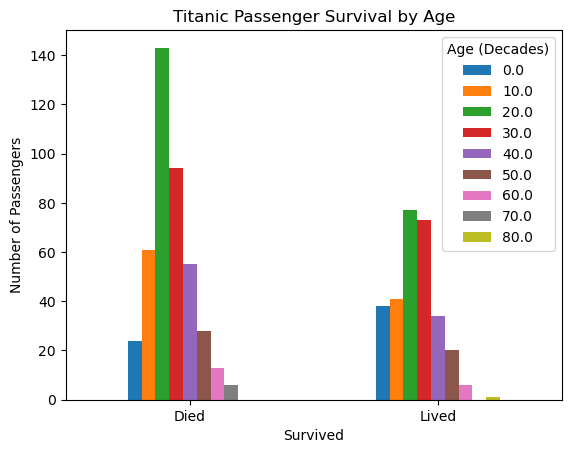

In [4]:
age_groups = df['Age'] // 10 * 10 # Group by decades
age_ct = pd.crosstab(df['Survived'], age_groups)
age_ct.plot(kind='bar', stacked=False, title='Titanic Passenger Survival by Age', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)
mlib.legend(title="Age (Decades)")

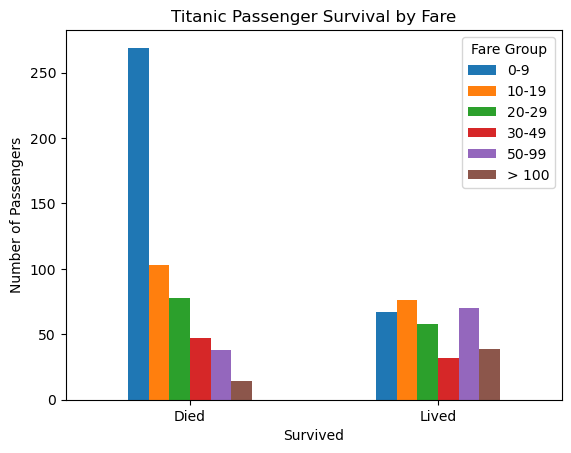

In [5]:
df.loc[df['Fare'] < 10, 'fare_group'] = "0-9"
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 20), 'fare_group'] = "10-19"
df.loc[(df['Fare'] >= 20) & (df['Fare'] < 30), 'fare_group'] = "20-29"
df.loc[(df['Fare'] >= 30) & (df['Fare'] < 50), 'fare_group'] = "30-49"
df.loc[(df['Fare'] >= 50) & (df['Fare'] < 100), 'fare_group'] = "50-99"
df.loc[(df['Fare'] >= 100), 'fare_group'] = "> 100" # lexographic sorting sucks >:[
fare_ct = pd.crosstab(df['Survived'], df['fare_group'])
fare_ct.plot(kind='bar', stacked=False, title='Titanic Passenger Survival by Fare', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)
mlib.legend(title='Fare Group')

([<matplotlib.axis.XTick at 0x2a3c519d950>,
 [Text(0, 0, 'Died'), Text(1, 0, 'Lived')])

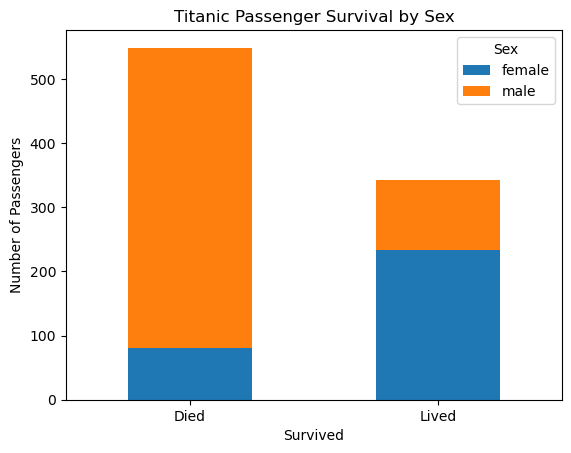

In [6]:
sex_ct = pd.crosstab(df['Survived'], df['Sex'])
sex_ct.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Sex', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)

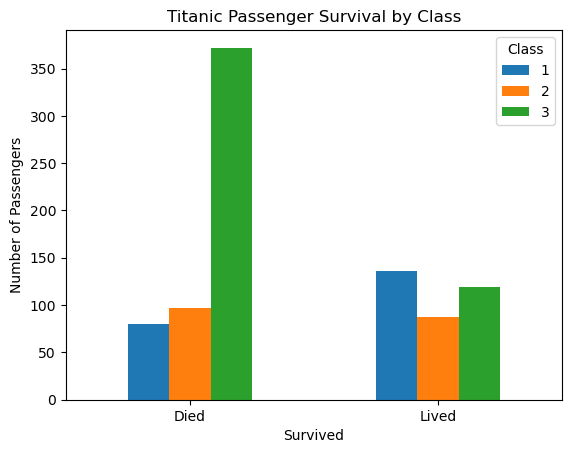

In [7]:
class_ct = pd.crosstab(df['Survived'], df['Pclass'])
class_ct.plot(kind='bar', stacked=False, title='Titanic Passenger Survival by Class', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)
mlib.legend(title='Class')

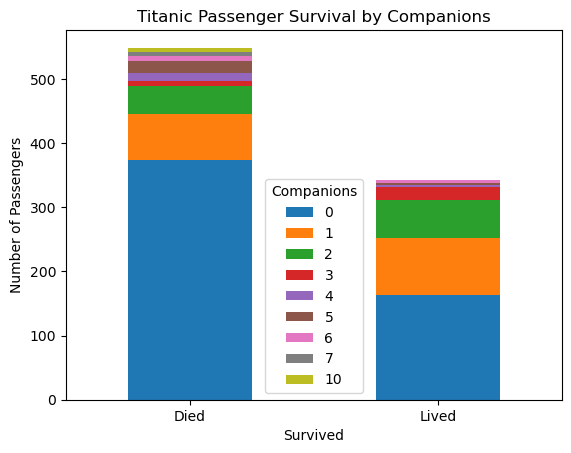

In [8]:
group_ct = pd.crosstab(df['Survived'], (df['SibSp'] + df['Parch']))
group_ct.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Companions', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)
mlib.legend(title='Companions')

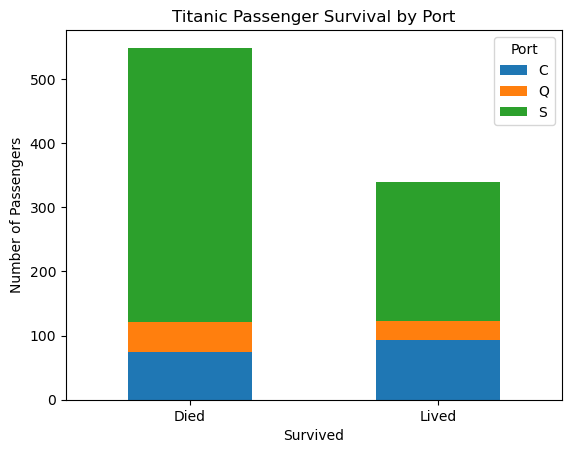

In [9]:
port_ct = pd.crosstab(df['Survived'], df['Embarked'])
port_ct.plot(kind='bar', stacked=True, title='Titanic Passenger Survival by Port', ylabel='Number of Passengers')
mlib.xticks([0, 1], ['Died', 'Lived'], rotation = 0)
mlib.legend(title='Port')

Most likely to survive
* Age: 20s
* Fare: 10-19
* Sex: Female
* Class: 1
* Companions: 0
* Port: S

In [11]:
filtered = df[
    (df['Age'] >= 20) & (df['Age'] < 30) &
    (df['Fare'] >= 10) & (df['Fare'] < 20) &
    (df['Sex'] == 'female') &
    (df['Pclass'] == 3) &
    (df['SibSp'] == 0) & (df['Parch'] == 0) &
    (df['Embarked'] == 'S')
    ]
filtered.head()

# Fare and class are conflicting. 1st class has no fare < 20.
# I elected to switch the class to 3rd. 
# The other option was to change the fare group higher.
# Between class and fare group, the class change output a single most likely survivor vs 4 from the fare increase.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,fare_group
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S,10-19


Gerda Dahlberg was traveling to her sister, who lived in Chicago Illinois

Least likely to survive  
**I opted for most likely to die instead of least likely to live. It makes more logical sense to me, given I'm too lazy to set up per-capita data :)*
* Age: 20s
* Fare: 0-9
* Sex: Male
* Class: 3
* Companions: 0
* Port: S

In [12]:
filtered = df[
    (df['Age'] >= 20) & (df['Age'] < 30) &
    (df['Fare'] < 10) &
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['SibSp'] == 0) & (df['Parch'] == 0) &
    (df['Embarked'] == 'S')
    ]
filtered.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,fare_group
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.05,NaN,S,0-9
37,38,0,3,"Cann, Mr. Ernest Charles",male,21.0,0,0,A./5. 2152,8.05,NaN,S,0-9
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.80,NaN,S,0-9
75,76,0,3,"Moen, Mr. Sigurd Hansen",male,25.0,0,0,348123,7.65,F G73,S,0-9
80,81,0,3,"Waelens, Mr. Achille",male,22.0,0,0,345767,9.00,NaN,S,0-9


Richard Nosworthy was not originally going to travel on the Titanic, instead seeking to board the Olympic. A railway disruption on his way to the port city ended up delaying his travel, causing him to take the Titanic instead
